### build a basic chatbot

In [7]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [8]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]


graph_builder=StateGraph(State)    

In [9]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model


model="llama3-8b-8192"
llm=init_chat_model("groq:llama-3.3-70b-versatile")
llm


ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000240E16F4E10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000240E1758890>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [10]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [11]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

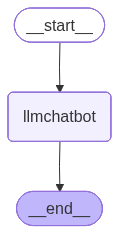

In [12]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [20]:
response=graph.invoke({"messages":"sup"})

In [21]:
response

{'messages': [HumanMessage(content='sup', additional_kwargs={}, response_metadata={}, id='6c2815d1-083b-492e-9938-4bac7a918eea'),
  AIMessage(content="Not much, just here to help. What's up with you?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 36, 'total_tokens': 51, 'completion_time': 0.049007656, 'completion_tokens_details': None, 'prompt_time': 0.004716442, 'prompt_tokens_details': None, 'queue_time': 0.785995235, 'total_time': 0.053724098}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e08de-12ee-7f52-9893-3ffa295b29d5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 15, 'total_tokens': 51})]}

In [28]:
for event in graph.stream({"messages":"why is cristiano better than messi"}):
    for value in event.values():
        print(value["messages"][-1].content)

A question that sparks a lot of debate among football fans. While both Cristiano Ronaldo and Lionel Messi are widely regarded as two of the greatest football players of all time, opinions on who is "better" tend to be subjective and often influenced by personal biases, team loyalties, and individual preferences. Here's a balanced analysis of both players' strengths and achievements:

**Cristiano Ronaldo's advantages:**

1. **Physicality and athleticism**: Ronaldo is known for his exceptional speed, power, and agility, which allows him to dominate games with his pace and strength.
2. **Goal-scoring consistency**: Ronaldo has consistently scored at an incredible rate throughout his career, with an average of over 40 goals per season.
3. **Trophy cabinet**: Ronaldo has won an impressive array of trophies, including five Ballon d'Or awards, four UEFA Champions League titles, and numerous league and cup titles with Manchester United, Real Madrid, and Juventus.
4. **Adaptability**: Ronaldo h

### Chatbot With Tool

In [1]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/',
   'title': 'What is LangGraph? - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions. By treating workflows as interconnected nodes and edges, LangGraph offers a scalable, transparent and developer-friendly way to design advanced AI systems ranging from simple chatbots to multi-agent system. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. By designing workflows, users combine multiple nodes into powerful, dynamic AI processes. * ****langgraph:**** Framework for bui

In [2]:
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [5]:
tools=[tool,multiply]
llm_with_tool=llm.bind_tools(tools)
llm_with_tool

RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000240E129CD50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000240E1404DD0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool deliv

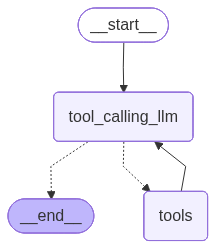

In [24]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
response=graph.invoke({"messages":"tell me how you are doing and then multiply 5 with 3"})
response['messages'][-1].content

"I'm doing well, thank you for asking. I'm a machine learning model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have."

In [28]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

tell me how you are doing and then multiply 5 with 3
================================== Ai Message ==================================

I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have.
Tool Calls:
  multiply (nzyfhg04g)
 Call ID: nzyfhg04g
  Args:
    a: 5
    b: 3
================================= Tool Message =================================
Name: multiply

15
================================== Ai Message ==================================

I'm doing well, thank you for asking. I'm a machine learning model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have.


In [23]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (6wy0erhqn)
 Call ID: 6wy0erhqn
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10
